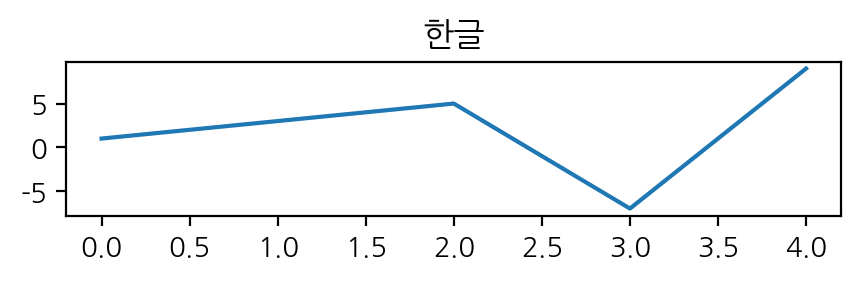

In [54]:
import re

import pandas as pd
import numpy as np

import koreanize_matplotlib
import matplotlib.pyplot as plt

# 그래프에 retina display 적용
%config InlineBackend.figure_format = 'retina'

pd.Series([1, 3, 5, -7, 9]).plot(title="한글", figsize=(5, 1));

In [55]:
# !pip install koreanize-matplotlib

In [56]:
#!pip install scikit-learn

In [57]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from tqdm import trange

In [58]:
# df 라는 변수에 이벤트 댓글 파일을 로드합니다.
df = pd.read_csv("data/inflearn/inflearn-event.csv")

print(df.shape)
df.head()    # 새해다짐 이벤트 댓글 개수는 2449개 

(2449, 1)


,text
0,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\n관심 있는 ...
1,"2020년 목표: C++ 열심히 공부해서, 학교에서 꼭 A 맞기..!! \n관심있는..."
2,2020년 목표 : 리액트 공부하기
3,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급
4,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!


In [59]:
# text 확인
for t in df['text'][:20]:
    print(t)
    print("-"*40)

2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!
관심 있는 강의 : 스프링 웹 MVC
----------------------------------------
2020년 목표: C++ 열심히 공부해서, 학교에서 꼭 A 맞기..!! 
관심있는 강의: ***C++
----------------------------------------
2020년 목표 : 리액트 공부하기
----------------------------------------
40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급
----------------------------------------
2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!
----------------------------------------
2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!
----------------------------------------
2020년 목표 : 리액트 공부하기, 스프링 공부하기
----------------------------------------
2020년에는 아이티 마스터가 되기 관심강의 리액트
#관심강의 : React로 NodeBird SNS 만들기
----------------------------------------
2020년에는 아이티 마스터가 되기 관심강의 리액트
----------------------------------------
2020년 더욱 성장하는 올해가 되었으면 합니다 !! ㅎㅎㅎㅎ 
관심강의 : Open CV ,  DL(tensorflow, keras, etc. ), NLP
----------------------------------------
올해는 작년보다 더 성장하길
관심강의: 선형대수학개론
----------------------------------------
2020년에는 대기업으로 이직하기!
----------------------------------------
2020년 목표 

# 데이터 전처리

### 네트워크 오류 등으로 발생한 중복 입력 값을 제거

In [60]:
# drop_duplicates 를 통해 중복을 제거하며, 이때 마지막 글을 남김
print(df.shape)
df = df.drop_duplicates(["text"], keep="last")
print(df.shape)   # 중복 제거한 새해다짐 이벤트 댓글 개수는 2410개 

(2449, 1)
(2410, 1)


### 원본은 따로 보존

In [61]:
# 전처리 전에 원본을 보존하기 위해 origin_text 라는 컬럼에 복사
df["origin_text"] = df["text"]

df.head(10)

,text,origin_text
0,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\n관심 있는 ...,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\n관심 있는 ...
1,"2020년 목표: C++ 열심히 공부해서, 학교에서 꼭 A 맞기..!! \n관심있는...","2020년 목표: C++ 열심히 공부해서, 학교에서 꼭 A 맞기..!! \n관심있는..."
3,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급
4,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!
5,2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!,2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!
6,"2020년 목표 : 리액트 공부하기, 스프링 공부하기","2020년 목표 : 리액트 공부하기, 스프링 공부하기"
7,2020년에는 아이티 마스터가 되기 관심강의 리액트\n#관심강의 : React로 N...,2020년에는 아이티 마스터가 되기 관심강의 리액트\n#관심강의 : React로 N...
8,2020년에는 아이티 마스터가 되기 관심강의 리액트,2020년에는 아이티 마스터가 되기 관심강의 리액트
9,2020년 더욱 성장하는 올해가 되었으면 합니다 !! ㅎㅎㅎㅎ \n관심강의 : Op...,2020년 더욱 성장하는 올해가 되었으면 합니다 !! ㅎㅎㅎㅎ \n관심강의 : Op...
10,올해는 작년보다 더 성장하길\n관심강의: 선형대수학개론,올해는 작년보다 더 성장하길\n관심강의: 선형대수학개론


### 소문자 변환

In [62]:
# 파이썬은 대소문자를 구분하기 때문에 데이터 필터링을 위해 대문자를 모두 소문자로 변경
df["text"] = df["text"].str.lower()
df["text"].head(10)

0     2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\n관심 있는 ...
1     2020년 목표: c++ 열심히 공부해서, 학교에서 꼭 a 맞기..!! \n관심있는...
3                 40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급
4                       2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!
5                     2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!
6                         2020년 목표 : 리액트 공부하기, 스프링 공부하기
7     2020년에는 아이티 마스터가 되기 관심강의 리액트\n#관심강의 : react로 n...
8                          2020년에는 아이티 마스터가 되기 관심강의 리액트
9     2020년 더욱 성장하는 올해가 되었으면 합니다 !! ㅎㅎㅎㅎ \n관심강의 : op...
10                       올해는 작년보다 더 성장하길\n관심강의: 선형대수학개론
Name: text, dtype: object

In [63]:
# 같은 의미의 단어를 하나로 통일 예) python => 파이썬, react => 리액트

# replace 는 텍스트가 완전히 일치될 때만 사용할 수 있음
# 일부만 일치한다면 str.replace 를 사용하면 원하는 텍스트로 변경이 가능
df["text"] = df["text"].str.replace(
    "python", "파이썬").str.replace(
    "pandas", "판다스").str.replace(
    "javascript", "자바스크립트").str.replace(
    "java", "자바").str.replace(
    "react", "리액트")
df.head(10)

,text,origin_text
0,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\n관심 있는 ...,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\n관심 있는 ...
1,"2020년 목표: c++ 열심히 공부해서, 학교에서 꼭 a 맞기..!! \n관심있는...","2020년 목표: C++ 열심히 공부해서, 학교에서 꼭 A 맞기..!! \n관심있는..."
3,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급
4,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!
5,2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!,2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!
6,"2020년 목표 : 리액트 공부하기, 스프링 공부하기","2020년 목표 : 리액트 공부하기, 스프링 공부하기"
7,2020년에는 아이티 마스터가 되기 관심강의 리액트\n#관심강의 : 리액트로 nod...,2020년에는 아이티 마스터가 되기 관심강의 리액트\n#관심강의 : React로 N...
8,2020년에는 아이티 마스터가 되기 관심강의 리액트,2020년에는 아이티 마스터가 되기 관심강의 리액트
9,2020년 더욱 성장하는 올해가 되었으면 합니다 !! ㅎㅎㅎㅎ \n관심강의 : op...,2020년 더욱 성장하는 올해가 되었으면 합니다 !! ㅎㅎㅎㅎ \n관심강의 : Op...
10,올해는 작년보다 더 성장하길\n관심강의: 선형대수학개론,올해는 작년보다 더 성장하길\n관심강의: 선형대수학개론


### 문자열 분리로 관심 강의 분리

In [64]:
df['text'][0]

'2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\n관심 있는 강의 : 스프링 웹 mvc'

In [65]:
df['text'][1]

'2020년 목표: c++ 열심히 공부해서, 학교에서 꼭 a 맞기..!! \n관심있는 강의: ***c++'

In [66]:
# 특정 기준으로 텍스트 분리 후 리스트로 저장.
df['text'][1].split("관심있는 강의")

['2020년 목표: c++ 열심히 공부해서, 학교에서 꼭 a 맞기..!! \n', ': ***c++']

In [67]:
# 이 이벤트에는 "관심강의"라는 텍스트가 있음 "관심강의"를 기준으로 텍스트를 분리하고 관심강의 뒤에 있는 텍스트를 가져옴

# 전처리한 내용은 실수를 방지하기 위해 "course" 라는 새로운 컬럼에 담고 "관심 강의", "관심 강좌" 에 대해서도 똑같이 전처리
# ":" 특수문자를 빈문자로 변경
df["course"] = df["text"].apply(lambda x: x.split("관심강의")[-1])
df["course"] = df["course"].apply(lambda x: x.split("관심 강의")[-1])
df["course"] = df["course"].apply(lambda x: x.split("관심 강좌")[-1])
df["course"] = df["course"].apply(lambda x: x.split("관심 있는 강의")[-1])
df["course"] = df["course"].apply(lambda x: x.split("관심있는 강의")[-1])
df["course"] = df["course"].str.replace(":", "")
df.head(10)

,text,origin_text,course
0,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\n관심 있는 ...,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\n관심 있는 ...,스프링 웹 mvc
1,"2020년 목표: c++ 열심히 공부해서, 학교에서 꼭 a 맞기..!! \n관심있는...","2020년 목표: C++ 열심히 공부해서, 학교에서 꼭 A 맞기..!! \n관심있는...",***c++
3,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급,40대 프로그래밍 시작! 우리를 위한 프로그래밍 파이썬 중급
4,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!,2020년 목표 돌머리 비전공자가 멋진 전공자 되기!
5,2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!,2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!,2020 년목표 비전공자(경영)가 전공자(it) 되기!!!
6,"2020년 목표 : 리액트 공부하기, 스프링 공부하기","2020년 목표 : 리액트 공부하기, 스프링 공부하기","2020년 목표 리액트 공부하기, 스프링 공부하기"
7,2020년에는 아이티 마스터가 되기 관심강의 리액트\n#관심강의 : 리액트로 nod...,2020년에는 아이티 마스터가 되기 관심강의 리액트\n#관심강의 : React로 N...,리액트로 nodebird sns 만들기
8,2020년에는 아이티 마스터가 되기 관심강의 리액트,2020년에는 아이티 마스터가 되기 관심강의 리액트,리액트
9,2020년 더욱 성장하는 올해가 되었으면 합니다 !! ㅎㅎㅎㅎ \n관심강의 : op...,2020년 더욱 성장하는 올해가 되었으면 합니다 !! ㅎㅎㅎㅎ \n관심강의 : Op...,"open cv , dl(tensorflow, keras, etc. ), nlp"
10,올해는 작년보다 더 성장하길\n관심강의: 선형대수학개론,올해는 작년보다 더 성장하길\n관심강의: 선형대수학개론,선형대수학개론


### 키워드 추출

In [68]:
# course 컬럼에 다음 키워드가 들어가는 댓글을 찾음
search_keyword = ['머신러닝', '딥러닝', '파이썬', '판다스', '공공데이터',
                  'django', '크롤링', '시각화', '데이터분석', 
                  '웹개발', '엑셀', 'c', '자바', '자바스크립트', 
                  'node', 'vue', '리액트']

# for문을 돌면서 위 키워드로 컬럼을 생성하고 
# course에 키워드가 들어있으면 True로 표시. 없으면 FALSE로 표시
# 원핫인코딩
for keyword in search_keyword:
    df[keyword] = df["course"].str.contains(keyword)
df.head(10)

,text,origin_text,course,머신러닝,딥러닝,파이썬,판다스,공공데이터,django,크롤링,시각화,데이터분석,웹개발,엑셀,c,자바,자바스크립트,node,vue,리액트
0,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\n관심 있는 ...,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\n관심 있는 ...,스프링 웹 mvc,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
1,"2020년 목표: c++ 열심히 공부해서, 학교에서 꼭 a 맞기..!! \n관심있는...","2020년 목표: C++ 열심히 공부해서, 학교에서 꼭 A 맞기..!! \n관심있는...",***c++,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급,40대 프로그래밍 시작! 우리를 위한 프로그래밍 파이썬 중급,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!,2020년 목표 돌머리 비전공자가 멋진 전공자 되기!,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!,2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!,2020 년목표 비전공자(경영)가 전공자(it) 되기!!!,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,"2020년 목표 : 리액트 공부하기, 스프링 공부하기","2020년 목표 : 리액트 공부하기, 스프링 공부하기","2020년 목표 리액트 공부하기, 스프링 공부하기",False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
7,2020년에는 아이티 마스터가 되기 관심강의 리액트\n#관심강의 : 리액트로 nod...,2020년에는 아이티 마스터가 되기 관심강의 리액트\n#관심강의 : React로 N...,리액트로 nodebird sns 만들기,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
8,2020년에는 아이티 마스터가 되기 관심강의 리액트,2020년에는 아이티 마스터가 되기 관심강의 리액트,리액트,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
9,2020년 더욱 성장하는 올해가 되었으면 합니다 !! ㅎㅎㅎㅎ \n관심강의 : op...,2020년 더욱 성장하는 올해가 되었으면 합니다 !! ㅎㅎㅎㅎ \n관심강의 : Op...,"open cv , dl(tensorflow, keras, etc. ), nlp",False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
10,올해는 작년보다 더 성장하길\n관심강의: 선형대수학개론,올해는 작년보다 더 성장하길\n관심강의: 선형대수학개론,선형대수학개론,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [69]:
df.shape  # 댓글 수는 2410개, 컬럼 수는 20개.

(2410, 20)

In [70]:
# text(댓글) 컬럼에서 파이썬 or 공공데이터 or 판다스 가 들어있는 데이터 찾기
# | (백슬래시) : shift + 원화표시
cond = df['text'].str.contains("파이썬|공공데이터|판다스")
df_python = df[cond]

print(df_python.shape)
df_python

(429, 20)


,text,origin_text,course,머신러닝,딥러닝,파이썬,판다스,공공데이터,django,크롤링,시각화,데이터분석,웹개발,엑셀,c,자바,자바스크립트,node,vue,리액트
3,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급,40대 프로그래밍 시작! 우리를 위한 프로그래밍 파이썬 중급,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
18,파이썬 데이터시각화 분석 실전 프로젝트 수강하고 싶어요,파이썬 데이터시각화 분석 실전 프로젝트 수강하고 싶어요,파이썬 데이터시각화 분석 실전 프로젝트 수강하고 싶어요,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False
21,머신러닝 제대로 배워보고 싶습니다.\n#관심강의 : 파이썬 머신러닝 완벽가이드,머신러닝 제대로 배워보고 싶습니다.\n#관심강의 : 파이썬 머신러닝 완벽가이드,파이썬 머신러닝 완벽가이드,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
25,"#관심강의: 프로그래밍 시작하기 : 파이썬 입문, 공공데이터로 파이썬 데이터 분석 ...","#관심강의: 프로그래밍 시작하기 : 파이썬 입문, 공공데이터로 파이썬 데이터 분석 ...","프로그래밍 시작하기 파이썬 입문, 공공데이터로 파이썬 데이터 분석 시작하기\n파...",False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False
29,자바기반 웹 개발자입니다. 데이터 분석에 많이 쓰이는 파이썬이 궁금합니다.\n#관심...,자바기반 웹 개발자입니다. 데이터 분석에 많이 쓰이는 Python이 궁금합니다.\n...,"프로그래밍 시작하기 파이썬 입문, 공공데이터로 파이썬 데이터 분석 시작하기",False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2427,"마음으로는 모든 강의가 듣고싶지만, 한가지씩 해나가고싶습니다. 우선은 파이썬부터 시...","마음으로는 모든 강의가 듣고싶지만, 한가지씩 해나가고싶습니다. 우선은 파이썬부터 시...",파이썬 사용자를 위한 웹개발 입문 a to z django + bootstrap,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False
2432,주니어개발자입니다. 토이프로젝트를 꼭 해보고 싶습니다. 올해엔 자바스크립트기초를 탄...,주니어개발자입니다. 토이프로젝트를 꼭 해보고 싶습니다. 올해엔 자바스크립트기초를 탄...,"파이썬입문과 크롤링기초 부트캠프 [쉽게! 하지만, 견고한 자료로!],node.js로...",False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False
2435,"올해는 파이썬과 r을 자유롭게 사용하고 싶어요..\n데이타 마이닝과, 업무능률향상 ...","올해는 파이썬과 R을 자유롭게 사용하고 싶어요..\n데이타 마이닝과, 업무능률향상 ...","올해는 파이썬과 r을 자유롭게 사용하고 싶어요..\n데이타 마이닝과, 업무능률향상 ...",False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2447,저번에 인프런에서 페이스북 마케팅 강의를 듣고 많은 도움을 받았습니다. 마케팅 업무...,저번에 인프런에서 페이스북 마케팅 강의를 듣고 많은 도움을 받았습니다. 마케팅 업무...,파이썬 입문 및 웹 크롤링을 활용한 다양한 자동화 어플리케이션 제작하기,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False


In [71]:
# 키워드들마다 등장 횟수 sum
df[search_keyword].sum().sort_values(ascending=False)

c         408
파이썬       403
자바        336
자바스크립트    140
리액트       136
머신러닝      132
vue       130
node      117
크롤링        56
딥러닝        51
django     31
시각화        30
웹개발        27
데이터분석      23
엑셀         18
공공데이터      12
판다스         6
dtype: int64

# 빈도수 계산을 위한 텍스트 데이터 벡터화

### BOW 단어 가방에 단어 토큰화

In [72]:
# 사이킷런의 CountVectorizer 를 통해 벡터화
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    min_df = 2,              # 토큰이 나타날 최소 문서 개수로 오타나 자주 나오지 않는 특수한 전문용어 제거에 좋음 
    ngram_range=(3, 6),      # BOW의 단위 갯수의 범위를 지정
    max_features = 2000      # 만들 피처의 수, 단어의 수
    )

vectorizer

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(3, ...)"
,analyzer,'word'


In [73]:
# df['course'] 만 벡터화
feature_vector = vectorizer.fit_transform(df['course'])

feature_vector.shape  # 댓글수 2410개, 단어 수 2000

(2410, 2000)

In [74]:
# 단어(코스) 확인|
vocab = vectorizer.get_feature_names_out()
print(len(vocab))
vocab[:20]    # 코스들 

2000


array(['12개 만들면서 배우는', '12개 만들면서 배우는 ios', '12개 만들면서 배우는 ios 아이폰',
       '12개 만들면서 배우는 ios 아이폰 개발', '12개를 만들며 배우는', '12개를 만들며 배우는 swift4',
       '12개를 만들며 배우는 swift4 ios11', '12개를 만들며 배우는 swift4 ios11 아이폰',
       '2018 do it', '2018 do it 안드로이드', '2018 do it 안드로이드 프로그래밍',
       '2020년 공부 목표', '2020년 공부 목표 올해는', '2020년 공부 목표 파이썬',
       '2020년 공부 목표 현재', '2020년 공부 목표는', '2020년 목표 리액트',
       '2020년 목표 리액트 공부하기', '2d 시작부터 배포까지', '3dsmax 초급부터 전문가까지'],
      dtype=object)

In [75]:
# 각 리뷰마다 등장하는 단어에 빈도수가 표현됨 (0 은 등장하지 않았음)
pd.DataFrame(feature_vector[:10].toarray(), columns=vocab).head()

,12개 만들면서 배우는,12개 만들면서 배우는 ios,12개 만들면서 배우는 ios 아이폰,12개 만들면서 배우는 ios 아이폰 개발,12개를 만들며 배우는,12개를 만들며 배우는 swift4,12개를 만들며 배우는 swift4 ios11,12개를 만들며 배우는 swift4 ios11 아이폰,2018 do it,2018 do it 안드로이드,...,활용2 api 개발과 성능 최적화,활용한 다양한 자동화,활용한 다양한 자동화 어플리케이션,활용한 다양한 자동화 어플리케이션 제작하기,활용한 데이터분석과 it보안,활용한 리액트 native,활용한 리액트 native 개발,활용한 메신져 만들기,활용한 메신져 만들기 android,활용한 파이썬 프로그래밍
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [76]:
# 위에서 구한 단어벡터를 더하면 단어가 전체에서 등장하는 횟수를 알 수 있음
# 벡터화 된 피처를 확인해 봄
# Bag of words 에 몇 개의 단어가 들어있는지 확인
dist = np.sum(feature_vector, axis=0)

# 언급이 많이 된 과목 확인
df_freq = pd.DataFrame(dist, columns=vocab)
df_freq

,12개 만들면서 배우는,12개 만들면서 배우는 ios,12개 만들면서 배우는 ios 아이폰,12개 만들면서 배우는 ios 아이폰 개발,12개를 만들며 배우는,12개를 만들며 배우는 swift4,12개를 만들며 배우는 swift4 ios11,12개를 만들며 배우는 swift4 ios11 아이폰,2018 do it,2018 do it 안드로이드,...,활용2 api 개발과 성능 최적화,활용한 다양한 자동화,활용한 다양한 자동화 어플리케이션,활용한 다양한 자동화 어플리케이션 제작하기,활용한 데이터분석과 it보안,활용한 리액트 native,활용한 리액트 native 개발,활용한 메신져 만들기,활용한 메신져 만들기 android,활용한 파이썬 프로그래밍
0,2,2,2,2,2,2,2,2,2,2,...,16,13,13,12,2,8,8,2,2,2


In [77]:
# 행과 열의 축을 T로 바꿔주고 빈도수로 정렬
df_freq.T.sort_values(by=0, ascending=False).head(30)

,0
스프링 데이터 jpa,59
nodebird sns 만들기,59
파이썬 머신러닝 완벽,49
리액트로 nodebird sns,49
머신러닝 완벽 가이드,49
리액트로 nodebird sns 만들기,49
파이썬 머신러닝 완벽 가이드,48
프로그래밍과 자바스크립트 es6,48
함수형 프로그래밍과 자바스크립트 es6,47
함수형 프로그래밍과 자바스크립트,47


In [78]:
df_freq_T = df_freq.T.reset_index()

# 컬럼명 새롭게 부여
df_freq_T.columns = ['course', 'freq']
df_freq_T.head(30)

,course,freq
0,12개 만들면서 배우는,2
1,12개 만들면서 배우는 ios,2
2,12개 만들면서 배우는 ios 아이폰,2
3,12개 만들면서 배우는 ios 아이폰 개발,2
4,12개를 만들며 배우는,2
5,12개를 만들며 배우는 swift4,2
6,12개를 만들며 배우는 swift4 ios11,2
7,12개를 만들며 배우는 swift4 ios11 아이폰,2
8,2018 do it,2
9,2018 do it 안드로이드,2


### 강의명 중복 제거

In [79]:
# 강의명을 앞에서 단어 4개 까지만 텍스트를 가져오고 다시 join으로 합쳐줌
' '.join("12개 만들면서 배우는 ios 아이폰 개발".split()[:4])

'12개 만들면서 배우는 ios'

In [80]:
# 강의명(course)에서 불필요한 정보(강사 이름 등)를 제거하고, 앞부분 키워드만 남겨 유사 강의를 하나로 묶어 중복을 확인
# 강의명을 중복제거하기 위해, 강좌명에서 지식공유자의 이름 제거
# 강의명을 앞에서 단어 4개 까지만 텍스트를 가져오고 다시 join으로 합쳐줌

df_freq_T["course_find"] = df_freq_T["course"].str.replace("박조은", "")
df_freq_T["course_find"] = df_freq_T["course_find"].apply(lambda x : " ". join(x.split()[:4]))

In [81]:
# 확인
df_freq_T.sort_values(["course_find", "freq"], ascending=False).head(20)

,course,freq,course_find
1999,활용한 파이썬 프로그래밍,2,활용한 파이썬 프로그래밍
1998,활용한 메신져 만들기 android,2,활용한 메신져 만들기 android
1997,활용한 메신져 만들기,2,활용한 메신져 만들기
1996,활용한 리액트 native 개발,8,활용한 리액트 native 개발
1995,활용한 리액트 native,8,활용한 리액트 native
1994,활용한 데이터분석과 it보안,2,활용한 데이터분석과 it보안
1992,활용한 다양한 자동화 어플리케이션,13,활용한 다양한 자동화 어플리케이션
1993,활용한 다양한 자동화 어플리케이션 제작하기,12,활용한 다양한 자동화 어플리케이션
1991,활용한 다양한 자동화,13,활용한 다양한 자동화
1989,활용2 api 개발과 성능,16,활용2 api 개발과 성능


In [82]:
# 긴 이름들이 토큰 4개로 정리된다. 
# 활용한 다양한 자동화 어플리케이션 제작하기 -> 활용한 다양한 자동화 어플리케이션
# 활용1 애플리케이션 개발 실전 스프링 부트와 -> 활용1 애플리케이션 개발 실전

In [83]:
# 그룹바이 전 과목의 freq 
df_freq_T[df_freq_T['course_find']=="12개 만들면서 배우는 ios"]

,course,freq,course_find
1,12개 만들면서 배우는 ios,2,12개 만들면서 배우는 ios
2,12개 만들면서 배우는 ios 아이폰,2,12개 만들면서 배우는 ios
3,12개 만들면서 배우는 ios 아이폰 개발,2,12개 만들면서 배우는 ios


In [84]:
# 그룹바이로 과목별 빈도수 합계
gr_course_freq = df_freq_T.groupby('course_find')[['freq']].sum()
gr_course_freq

,freq
course_find,
12개 만들면서 배우는,2
12개 만들면서 배우는 ios,6
12개를 만들며 배우는,2
12개를 만들며 배우는 swift4,6
2018 do it,2
...,...
활용한 리액트 native,8
활용한 리액트 native 개발,8
활용한 메신져 만들기,2


In [85]:
# 빈도수 기준 정렬
df_grouped = gr_course_freq.reset_index().sort_values(by='freq', ascending=False)
df_grouped.head(20)
# temp[temp['course_find'].str.contains("만들면서 배우는 ios")]

,course_find,freq
775,실전 스프링 부트와 jpa,116
910,위한 알고리즘 입문 with,93
1011,자바 orm 표준 jpa,92
135,it 취업을 위한 알고리즘,90
1116,취업을 위한 알고리즘 입문,90
720,스프링 부트와 jpa 활용1,72
712,스프링 기반 rest api,66
1295,함수형 프로그래밍과 자바스크립트 es6,66
217,orm 표준 jpa 프로그래밍,61
488,누구든지 하는 리액트 초심자를,60


In [86]:
# 언급이 많이 되는 과목 확인

# KMeans 군집화 준비

In [87]:
# TF-IDF 벡터화 (모델링 전 준비단계)
# KMeans 군집화

In [88]:
feature_vector

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 11156 stored elements and shape (2410, 2000)>

In [89]:
from sklearn.feature_extraction.text import TfidfTransformer
tfidftrans = TfidfTransformer(smooth_idf=False)
tfidftrans

,norm,'l2'
,use_idf,True
,smooth_idf,False
,sublinear_tf,False


In [90]:
# 예전에 만들어두었던 전체 댓글의 단어 카운트 벡터(feature_vector)에 대해 TF-IDF 적용
feature_tfidf = tfidftrans.fit_transform(feature_vector)
feature_tfidf.shape

(2410, 2000)

In [91]:
# 데이터프레임으로 확인
tfidf_freq = pd.DataFrame(feature_tfidf.toarray(), columns=vocab)
tfidf_freq.head()  

,12개 만들면서 배우는,12개 만들면서 배우는 ios,12개 만들면서 배우는 ios 아이폰,12개 만들면서 배우는 ios 아이폰 개발,12개를 만들며 배우는,12개를 만들며 배우는 swift4,12개를 만들며 배우는 swift4 ios11,12개를 만들며 배우는 swift4 ios11 아이폰,2018 do it,2018 do it 안드로이드,...,활용2 api 개발과 성능 최적화,활용한 다양한 자동화,활용한 다양한 자동화 어플리케이션,활용한 다양한 자동화 어플리케이션 제작하기,활용한 데이터분석과 it보안,활용한 리액트 native,활용한 리액트 native 개발,활용한 메신져 만들기,활용한 메신져 만들기 android,활용한 파이썬 프로그래밍
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [92]:
# 과목별 TFIDF값 합산 및 정렬
df_tfidf = pd.DataFrame(tfidf_freq.sum(), columns=["TFIDF"])
df_tfidf_top = df_tfidf.sort_values(by="TFIDF", ascending=False)
df_tfidf_top.head(20)

,TFIDF
스프링 데이터 jpa,35.177810
파이썬 실전 활용,27.436956
nodebird sns 만들기,27.344028
머신러닝 완벽 가이드,24.940049
파이썬 머신러닝 완벽,24.940049
리액트로 nodebird sns 만들기,24.793831
리액트로 nodebird sns,24.793831
파이썬 머신러닝 완벽 가이드,24.040881
프로그래밍과 자바스크립트 es6,19.740754
따라하며 배우는 c언어,18.832220


# KMeans 문서 군집화

In [93]:
# 목적은 비슷한 강의끼리 군집화하는 것.
# 고객의 니즈 파악

### inertia 이용해서 적절한 클러스터 갯수 찾기

In [94]:
# 생략
# inertia는 군집 내부가 얼마나 촘촘한지 보는 값
# "각 데이터가 자기 클러스터 중심에서 얼마나 떨어져 있는가"를 합친 값
# - inertia가 무조건 작다고 좋은 건 아닙니다. 클러스터 수를 늘리면 보통 계속 작아지기 때문입니다.
# - 그래서 감소가 크다가 어느 순간부터 완만해지는 지점(엘보우 지점)을 고릅니다.
# - 그 지점이 "클러스터를 더 늘려도 얻는 이득이 크지 않은 군집 수"입니다.

### KMeans 학습

In [95]:
# 클러스터를 몇 개로 나눌지 정함
n_clusters = 30   # 데이터를 30개의 그룹으로 나누겠다는 뜻

# KMeans 모델 생성
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# TF-IDF로 벡터화된 데이터(feature_tfidf)를 가지고
# KMeans 모델을 학습시킴
# 즉, 비슷한 댓글/강의명끼리 자동으로 묶는 기준을 찾음
kmeans.fit(feature_tfidf)

,n_clusters,30
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [96]:
# 학습된 모델을 사용해서 각 데이터가 어느 클러스터(그룹)에 속하는지 예측
# 결과는 예를 들어 [3, 10, 3, 21, 7, ...] 같은 형태
prediction = kmeans.predict(feature_tfidf)
df["cluster"] = prediction

In [97]:
# 댓글 별로 어떻게 클러스터가 배정되었는지 확인
df[ ['text', 'course', 'cluster'] ]
# text -> course -> tfidf 벡터화 -> cluster

,text,course,cluster
0,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\n관심 있는 ...,스프링 웹 mvc,0
1,"2020년 목표: c++ 열심히 공부해서, 학교에서 꼭 a 맞기..!! \n관심있는...",***c++,0
3,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급,40대 프로그래밍 시작! 우리를 위한 프로그래밍 파이썬 중급,0
4,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!,2020년 목표 돌머리 비전공자가 멋진 전공자 되기!,0
5,2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!,2020 년목표 비전공자(경영)가 전공자(it) 되기!!!,0
...,...,...,...
2444,"작년 한해도 일이 바쁘다, 야근해서 힘들다는 핑계로 ***님의 jpa 강의를 또 스...",스프링 데이터 jpa,9
2445,저는 졸업을 1년 남기고 있는 컴퓨터공학과 학생입니다. 졸업 프로젝트로 웹/앱 개발...,스프링 부트 개념과 활용,3
2446,"에프터 이펙트를 써본 적은 있는데, 매번 기초만 배우다 말았어요. 이걸 할 줄 안다...",에펙 초보자도 만들 수 있는 유튜브 인트로 에프터이펙트 강좌,0
2447,저번에 인프런에서 페이스북 마케팅 강의를 듣고 많은 도움을 받았습니다. 마케팅 업무...,파이썬 입문 및 웹 크롤링을 활용한 다양한 자동화 어플리케이션 제작하기,17


In [98]:
# cluster 별 빈도수 확인
df["cluster"].value_counts()

cluster
0     1863
7       46
2       43
5       39
18      32
1       30
12      26
25      26
3       25
10      24
20      24
9       23
6       22
4       22
19      18
27      16
14      15
16      13
21      13
17      13
13      12
15      11
11      10
29       9
22       9
28       6
26       6
8        5
23       5
24       4
Name: count, dtype: int64

In [99]:
# 클러스터 별 5개씩 강의 확인
top5_courses = (
    df.groupby("cluster")["course"]
      .value_counts()
      .groupby(level=0)
      .head(5)
      .reset_index(name="count")
)

top5_courses[:50]   # 상위 50개만 확인

,cluster,course,count
0,0,***의 따라하며 배우는 c++,24
1,0,스프링 웹 mvc,17
2,0,***의 따라하며 배우는 c++,10
3,0,선형대수학개론,7
4,0,스프링 시큐리티,7
5,1,it 취업을 위한 알고리즘 입문 (with c++) 창의적 문제해결,13
6,1,it 취업을 위한 알고리즘 입문 (with c++) 창의적 문제해결,5
7,1,it 취업을 위한 알고리즘 입문 (with c++) 창의적 문제해결,3
8,1,\n 자바스크립트 핵심 개념 알아보기 - js flow\n실습 ui 개발로 배워보는...,1
9,1,\nit 취업을 위한 알고리즘 입문 (with c++) 창의적 문제해결,1


# Kmeans 클러스터링 평가

In [100]:
# Kmeans 문서 군집화 평가 가이드
# 1. 실루엣 점수를 통해 전체적인 구조가 논리적인지 확인하세요.
# 2. 클러스터별 키워드를 출력하여 사람이 읽었을 때 "아, 이 그룹은 OO 관련 내용이구나"라고 이해되는지 확인하는 것이 가장 중요합니다.
# 3. 만약 키워드가 서로 너무 겹친다면 n_clusters 숫자를 줄이거나, 불용어(Stopwords) 처리를 강화해야 합니다.

### 실루엣 스코어

In [101]:
from sklearn.metrics import silhouette_score

# 전체 데이터에 대한 실루엣 점수 계산
# 데이터가 너무 많으면 시간이 오래 걸릴 수 있습니다.
score = silhouette_score(feature_tfidf, kmeans.labels_)
print(f"실루엣 점수: {score:.4f}")

실루엣 점수: 0.4872


✅ 이미지가 my_silhouette_analysis.png으로 저장되었습니다.


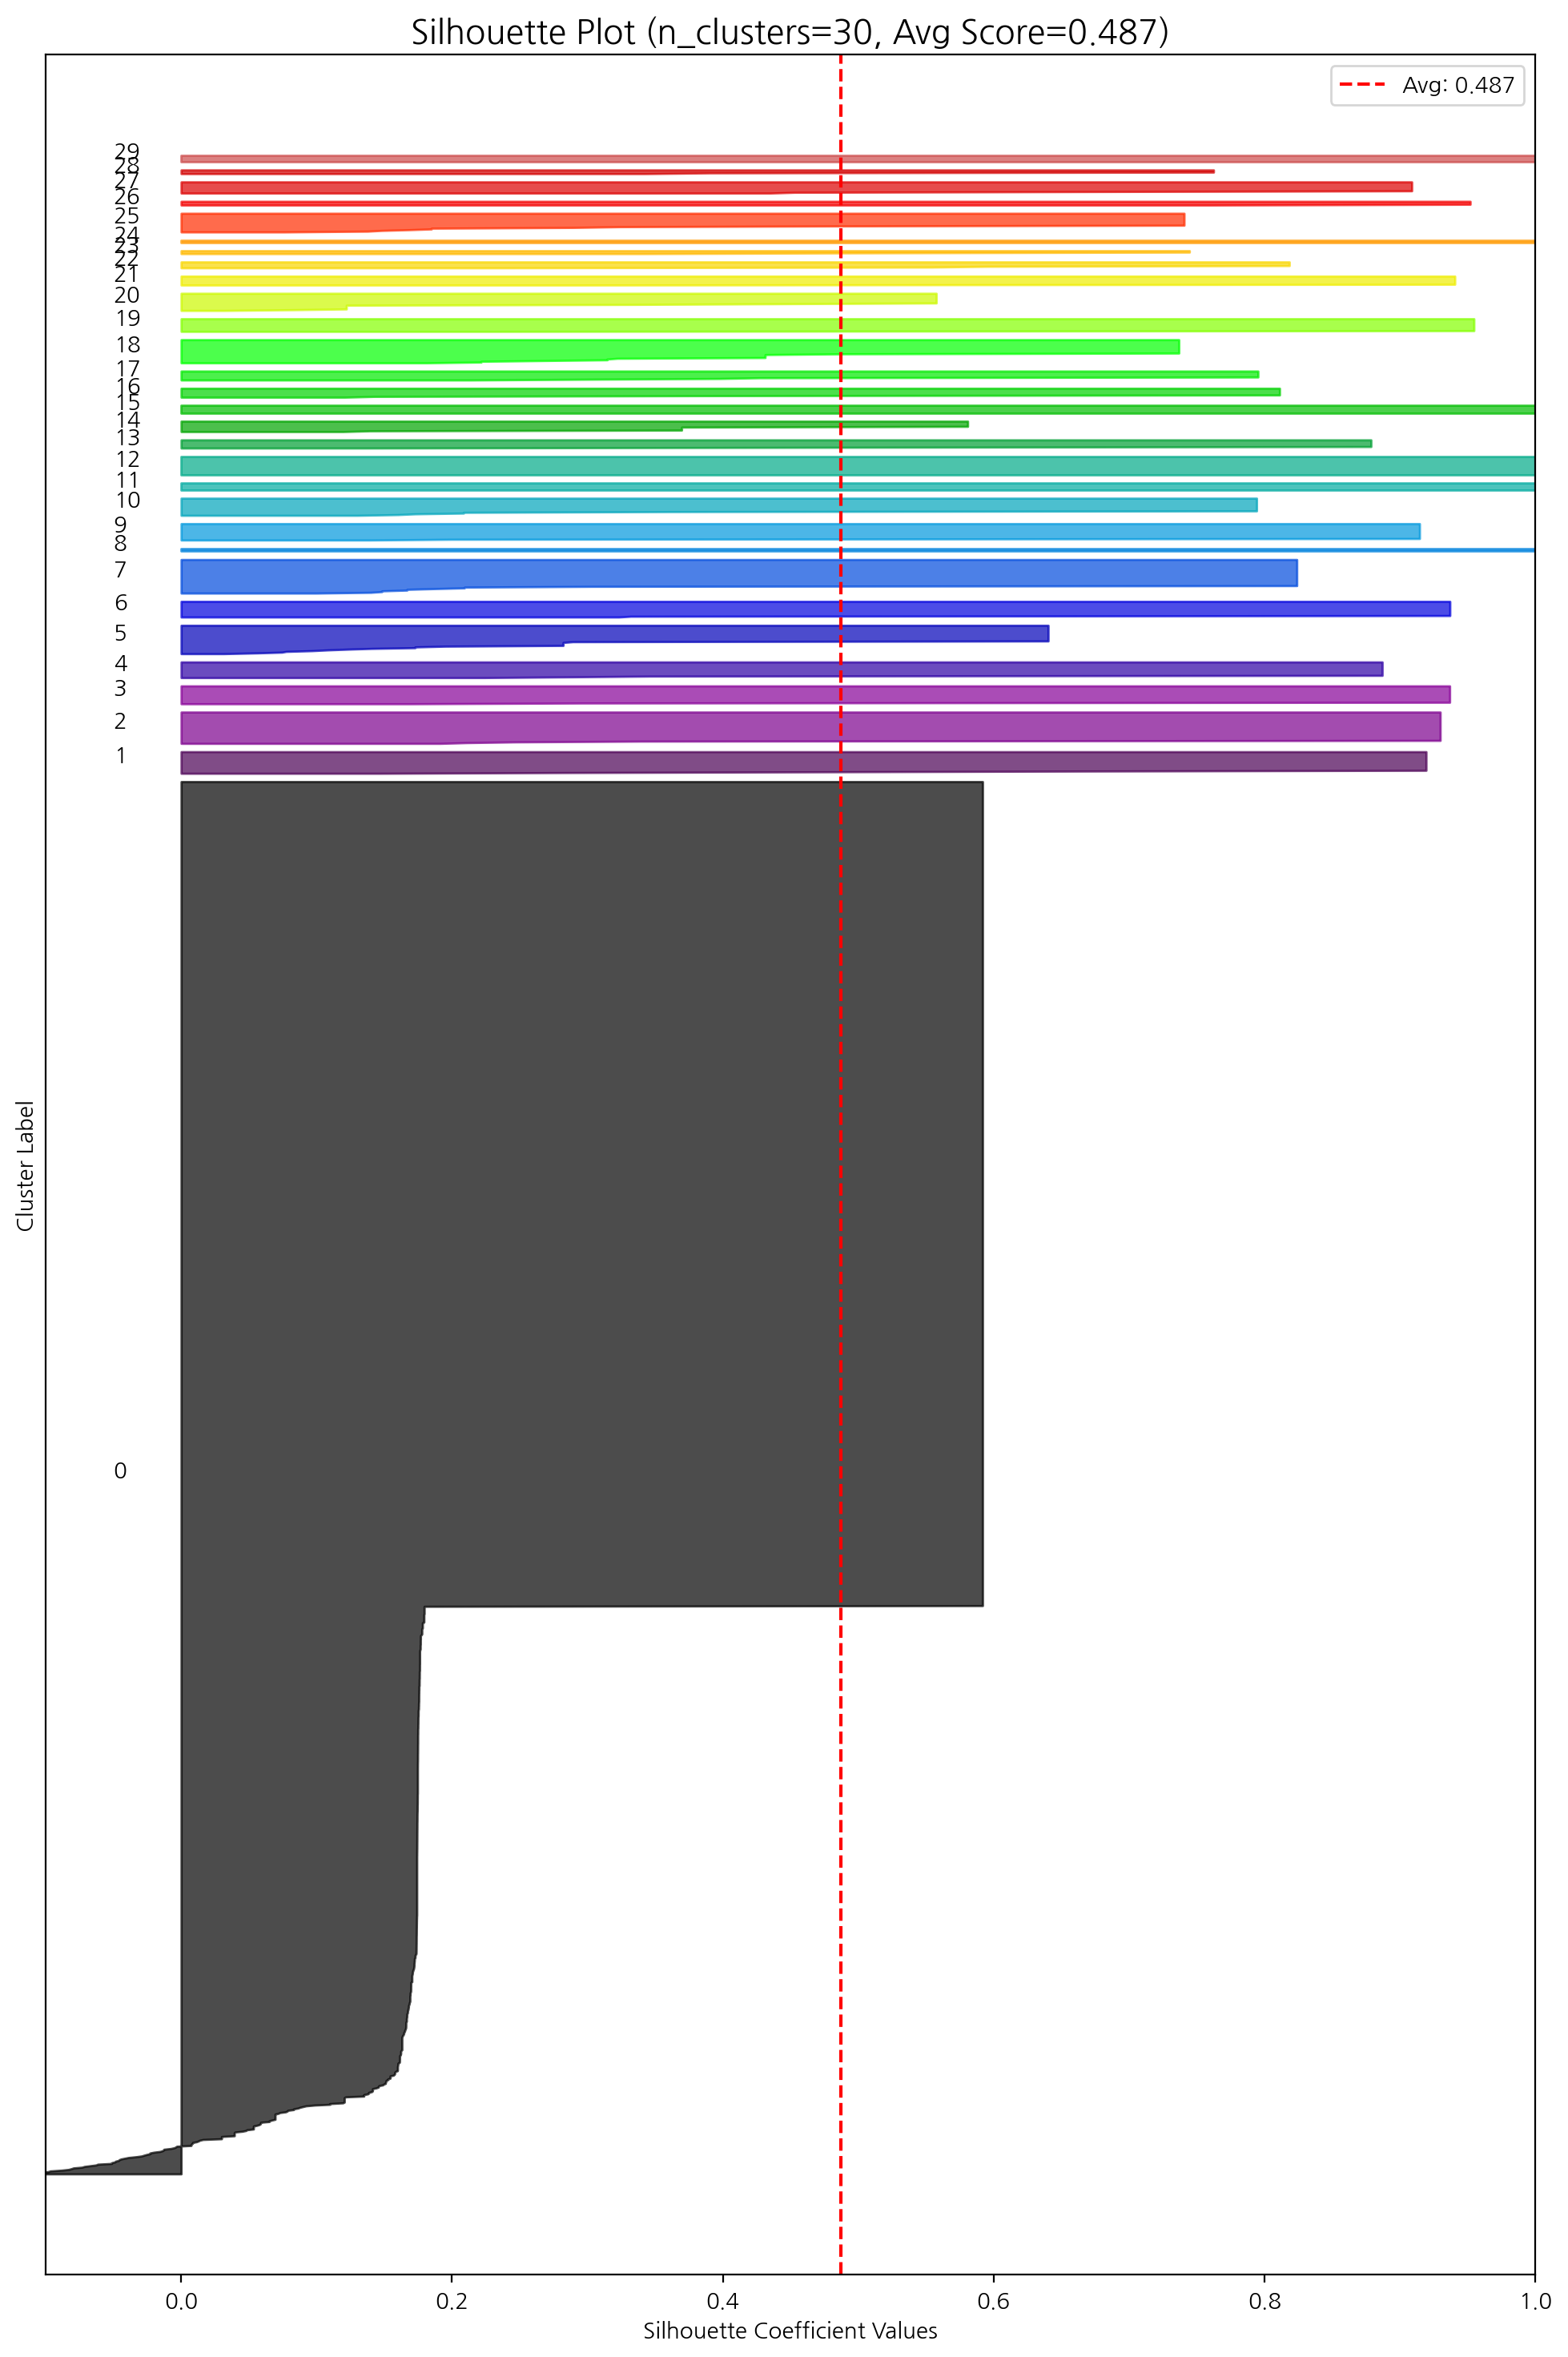

In [102]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from sklearn.metrics import silhouette_samples, silhouette_score

def save_silhouette_plot(n_clusters, feature_tfidf, kmeans_labels, filename="silhouette_plot.png"):
    # 1. 실루엣 점수 계산
    avg_score = silhouette_score(feature_tfidf, kmeans_labels)
    sample_values = silhouette_samples(feature_tfidf, kmeans_labels)

    # 2. 그래프 설정 (30개 클러스터이므로 세로 길이를 충분히 확보)
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(12, 18)  # 가로 12, 세로 18 인치

    y_lower = 10
    for i in range(n_clusters):
        # 각 클러스터별 점수 추출 및 정렬
        ith_cluster_values = sample_values[kmeans_labels == i]
        ith_cluster_values.sort()

        size_cluster_i = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster_i

        # 색상 지정
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # 클러스터 번호 라벨링
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10  # 다음 클러스터와의 간격

    # 그래프 꾸미기
    ax1.set_title(f"Silhouette Plot (n_clusters={n_clusters}, Avg Score={avg_score:.3f})", fontsize=15)
    ax1.set_xlabel("Silhouette Coefficient Values")
    ax1.set_ylabel("Cluster Label")

    # 평균 실루엣 점수 빨간 점선
    ax1.axvline(x=avg_score, color="red", linestyle="--", label=f"Avg: {avg_score:.3f}")
    ax1.set_yticks([])  # y축 눈금 제거
    ax1.set_xlim([-0.1, 1]) # 실루엣 계수 범위
    ax1.legend()

    # --- 이미지 파일 저장 ---
    # dpi=300: 인쇄 수준 고해상도
    # bbox_inches='tight': 여백 없이 꽉 채워서 저장 (라벨 잘림 방지)
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✅ 이미지가 {filename}으로 저장되었습니다.")
    
    plt.show()

# --- 실행 및 다운로드 ---
save_silhouette_plot(n_clusters, feature_tfidf, kmeans.labels_, "my_silhouette_analysis.png")

# 만약 Google Colab 사용 중이라면 아래 코드 주석을 해제하여 바로 다운로드하세요.
# from google.colab import files
# files.download("my_silhouette_analysis.png")

In [103]:
# 실루엣 스코어 결과 해석해줘

# 📊 KMeans 클러스터링 실루엣 분석 보고서

## 1. 결과 요약 (Executive Summary)
- **평균 실루엣 점수:** **0.487** (중상위 수준)
- **주요 현상:** - **Cluster 0**에 전체 데이터의 과반수가 몰려 있는 '거대 군집' 현상 발생.
    - **Cluster 1~29**는 데이터 수는 적으나 응집도가 매우 높은 '특화 군집'으로 형성됨.
- **결론:** 전반적인 주제 분리는 성공적이나, 특징이 모호한 데이터(Cluster 0)의 세분화가 필요함.

---

## 2. 상세 해석 (Detailed Analysis)

### ✅ 실루엣 점수 (0.487)
텍스트 데이터는 차원이 매우 높고 노이즈가 많아 보통 0.5를 넘기기 어렵습니다. 현재 점수는 모델이 데이터 간의 논리적 구분을 어느 정도 수행했음을 의미하는 **양호한 지표**입니다.

### ✅ Cluster 0 (The Giant/Noise Cluster)
- **특징:** 그래프 하단의 거대한 회색 영역. 데이터 개수가 너무 많고 실루엣 계수가 낮음.
- **원인:** - "좋아요", "수고하셨습니다", "감사합니다"와 같은 **공통적인 인사말**이나 **불용어**가 섞여 있을 가능성이 높음.
    - 특징이 뚜렷하지 않은 일반적인 리뷰/강의명이 하나로 뭉쳐진 상태.
- **리스크:** 음수 영역(0.0 왼쪽)으로 뻗은 데이터들은 현재 잘못 분류되었을 확률이 높음.

### ✅ Cluster 1~29 (Specialized Clusters)
- **특징:** 폭은 좁지만 길이가 매우 긴(1.0에 가까운) 형태.
- **해석:** 특정 기술 스택, 구체적인 질문, 혹은 매우 독특한 키워드를 포함한 데이터들이 **매우 정교하게 그룹화**됨. (예: 특정 라이브러리 언급, 에러 코드 포함 등)

---

## 🚀 향후 개선 전략 (Action Plan)

### 1단계: Cluster 0 데이터 정밀 진단
- **Action:** Cluster 0에 속한 텍스트들만 따로 추출하여 **가장 빈번하게 등장하는 단어(Top Keywords)**를 확인합니다.
- **Goal:** 의미 없는 반복 단어를 찾아 **불용어(Stopwords) 리스트에 추가**하고 모델을 재학습시킵니다.

### 2단계: 클러스터 개수(K) 최적화
- **Action:** 현재 30개의 클러스터 중 일부는 데이터가 너무 적으므로, $K$값을 15~20 사이로 줄여 봅니다.
- **Goal:** 너무 쪼개진 특화 군집들을 통합하고, Cluster 0의 데이터들이 다른 의미 있는 군집으로 분산될 수 있도록 유도합니다.

### 3단계: 2단계 계층적 클러스터링 (Hierarchical Clustering)
- **Action:** 이미 잘 분류된 1~29번 군집은 유지하고, **Cluster 0번에 속한 데이터만 따로 떼어내어** 다시 KMeans를 수행합니다.
- **Goal:** 거대한 잡동사니 군집 내부에서 숨겨진 소주제들을 추가로 발굴합니다.

### 4단계: 실루엣 계수 기반 데이터 필터링
- **Action:** 실루엣 계수가 **0 이하인 데이터(잘못 분류된 데이터)**를 분석 대상에서 제외하거나 '미분류' 그룹으로 정의합니다.
- **Goal:** 분석 결과의 신뢰도를 높이고 핵심 인사이트에 집중합니다.